In [ ]:
# default_exp fitting

In [ ]:
#hide
%load_ext autoreload
%autoreload 2

from nbdev.showdoc import *

The autoreload extension is already loaded. To reload it, use:
  %reload_ext autoreload


# Fitting Funcs
> This notebook holds all the machinery needed to fit the models and calc the errors<br>
> TODO:
> * Add hover daata in DfFit plot
> * CREATE A PLOT_GROU_FIT in the Group_fit_class
> * Create also a PLOT MULTIFIT, plot the best fit (axis of the best fit) and other fits as additional curves (other X axis ?!?!))

In [ ]:
#export

import io
import numpy as np
import matplotlib
import matplotlib.pyplot as plt

import plotly
import plotly.io as pio
import plotly.express as px
import plotly.graph_objects as go
from IPython.core.display import display, HTML


import pyarrow

import pandas as pd

from WaterClassification import core
from WaterClassification import cleaning

from scipy.optimize import curve_fit

from sklearn.metrics import r2_score, mean_squared_error

import math

import parser

import warnings
warnings.filterwarnings('ignore')

To load the data that will be used throughout this notebook, we will use `load_and_clean` function defined in [Data Preparation](https://cordmaur.github.io/WaterClassification/Data_Preparation/) notebook<br>


In [ ]:
#hide
csv = './data/reflectances_3.csv'
df = cleaning.load_and_clean(csv, flag_col='320', 
                             bad_flags=['não rodou', 'ruim'],
                             wl_range = cleaning.wavelength_range(375, 940),
                             clean_missing=True,
                             clean_neg=True,
                             clean_SPM_column='SPM',
                            )

# There are two measurements with outliar reflectances (identified by the graphs)
df = cleaning.delete_rows(df, [997, 998])

df = cleaning.calc_area(df)
df_norm = cleaning.normalize(df)

Deleting 5 rows with bad_flags: [925, 931, 932, 933, 934]
Deleting 7 rows with missing values (from 375 to 940nm): [213, 358, 370, 383, 391, 415, 541]
Deleting 51 rows with negative values (from 375 to 940nm): [590, 600, 619, 653, 667, 724, 725, 726, 727, 729]
Deleting 8 rows with missing SPM values in SPM: [487, 498, 499, 542, 543, 544, 547, 551]


## Simple Fitting (Fit class)
The fit class permits to receive a bunch of X, y data and fit a model to it. It also plots the graph.

In [ ]:
#export
## To solve convergence problems?
#https://stackoverflow.com/questions/56164659/scipy-curve-fit-do-not-converge-even-if-i-iteratively-change-initial-guess

class Fit:
    "Class that stores a fitting. It has hooks to original data and fitted parameters."

    available_funcs = ['linear', 'expo', 'power', 'nechad']
    
    def __init__(self, func, X, y, metrics=['r2', 'rmse', 'SSE']):
        "Fits a model (function) to a set of data (X, y). Return the parameters and the errors as a dictionary."
        
        self.metrics = metrics

        try:
            popt, pcov = curve_fit(Fit.get_func(func), X, y, check_finite=False,)
            self.fit_params = Fit.test_fit(X, y, func, popt, metrics=metrics)

        except:
            self.fit_params = {}

        # Flag the forces the output graphs as HTML for display at github
        self.publish=False

    #################################  FITTING METHODS  #################################
    @staticmethod
    def test_fit(X, y, func, params=[], decimal=4, metrics=['r2', 'rmse', 'SSE']):
        "Compute the predictions, calculate the errors and return in a dictionary. If there is no func, assume X is already the y_hat"
        res = {}

        y_hat = np.array(X) if func is None else Fit.apply_func(np.array(X), func, params)

        if 'r2' in metrics: res.update({'r2': round(r2_score(y, y_hat), decimal)})
        if 'rmse' in metrics: res.update({'rmse': round(math.sqrt(mean_squared_error(y, y_hat)), decimal)})
        if 'SSE' in metrics: res.update({'SSE': round(((y-y_hat)**2).sum(), decimal)})

        if 'rmsle' in metrics: res.update({'rmsle': round(np.sqrt(np.mean(np.square(np.log1p(y) - np.log1p(y_hat)))))})

        res.update({'func': Fit.func_name(func) if func is not None else None, 
                    'params': params, 
                    'qty': len(X), 
                    'X': None if func is None else X, 
                    'y': y, 
                    'y_hat': y_hat})
        
        return res
    
    #################################  GRAPHING METHODS  #################################
    def get_func_trace(self, func, params, pts=200, add_metrics=False):
        "Returns a function trace adjusted to this Fit's X range. Func can be either str or function"
        xs = np.linspace(np.min(self.fit_params['X']), np.max(self.fit_params['X']), pts) 
        ys = self.apply_func(xs, func, params)
        
        txt_metrics = ''
        for metric in self.metrics: txt_metrics += f'{metric}: {self.fit_params[metric]}<br>'
        
        return go.Scatter(x=xs, y=ys, mode='lines', name=self.get_func(func).__name__, text=f'Params:{params}<br>' + txt_metrics)
    
    def plot_fit(self, df=None, new_funcs=[], new_params=[], pts=200, fig = None, position=(1, 1), **kwargs):
        "Plots the fit (data and curve). If existing fig is passed, the position parameter indicates where (row, col tuple) it will be placed in a given figure"
        scatter_plot = px.scatter(df, x=self.fit_params['X'], y=self.fit_params['y'], **kwargs)

        fig = scatter_plot if fig is None else core.apply_subplot(fig, scatter_plot, position)
  
        # Add the original fit trace
        fig.add_trace(self.get_func_trace(self.func, self.fit_params['params'], add_metrics=True), row=position[0], col=position[1])
        
        for new_func, new_param in zip(new_funcs, new_params):
            fig.add_trace(self.get_func_trace(new_func, new_param), row=position[0], col=position[1])
            
        return self.showfig(fig)
    
    
    def showfig(self, fig, buttonsToRemove=[]):
        "Converts a plotly figure into a HTML graph and displays it. That is necessary to maintain the interactive functionality of plotly in the jekyll documentation, on Github."
        if self.publish: showfig(fig)
        return fig
    
    
    def get_param(self, param_name, default_value=None): return self.fit_params.get(param_name, default_value)
    
    #################################  FUNCTION METHODS  #################################
    @property
    def func(self): return Fit.get_func(self.get_param('func'))

    @staticmethod
    def apply_func(x, func, params): return Fit.get_func(func)(x, *params)

    @staticmethod
    def get_func(func): return getattr(Fit, func) if isinstance(func, str) else func
    
    @staticmethod
    def func_name(func): return Fit.get_func(func).__name__
    
    @staticmethod
    def nir_red_ratio(x, a, b):
        return a * np.power(x, b)
    
    @staticmethod
    def linear(x, a, b): return a*x+b

    @staticmethod
    def expo(x, a, b): return a*10**x+b

    @staticmethod
    def power(x, a, b, c):return a*(x)**(b)+c

    @staticmethod
    def poly(x, a, b, c, d):return a*x**b+c*x+d

    @staticmethod
    def nechad(red, a=610.94, c=0.2324): return a * red / (1 - (red / c))

    #################################  OTHER METHODS  #################################
    def filled(self):
        return 'r2' in self.fit_params.keys()
    
    def __repr__(self):
        if not self.filled():
            return 'Empty fitting'

        s = f"{self.fit_params['func']} func | "
        for key in ['r2', 'rmse', 'SSE', 'qty', 'params']:
            s += f"{key}: {self.fit_params[key]} "
            
        return s

In [ ]:
# Example: Fit a linear function to the whole serie of data
fit = Fit('linear', df['865'], df['SPM'])
fit

linear func | r2: 0.7037 rmse: 68.774 SSE: 4398771.2987 qty: 930 params: [ 1.03818344e+04 -7.43372055e+00] 

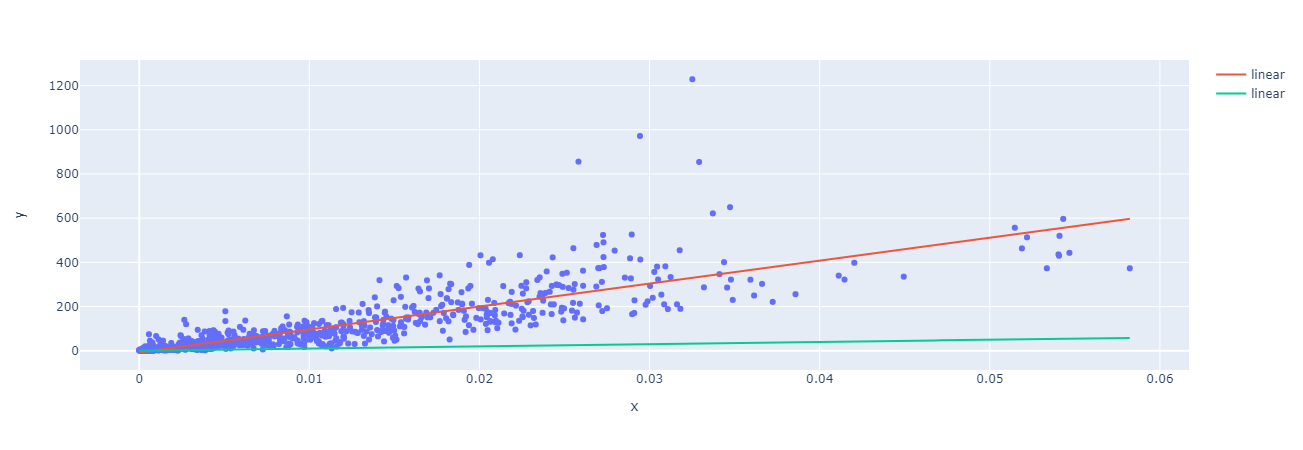

In [ ]:
# The fit object also allows us to plot the model curve and publish flag controls the HTML display for documentation purpose
fit.publish = False
fit.plot_fit(new_funcs=['linear'], new_params=[(1000, 0)])

The Fit class has the list of all available functions `Fit.available_funcs`.<br>
Also, as metadata, the `fit` objects hold all the information needed to reproduce the fit latter:

In [ ]:
print(f'Available functions: {Fit.available_funcs}')
print(f'Metadata parameters: {fit.fit_params.keys()}')

Available functions: ['linear', 'expo', 'power', 'nechad']
Metadata parameters: dict_keys(['r2', 'rmse', 'SSE', 'func', 'params', 'qty', 'X', 'y', 'y_hat'])


## Dataframe Fit (DfFit)
The dataframe fit DfFit class, extends the Fit class, by adding support to work with Pandas dataframes instead of raw data. <br>
The data (independent-X and dependent-Y) shall be in the columns.<br>
Additionally, it adds functionality to parse simple functions, as explained in `Fit.parse_expr_df`.

In [ ]:
#export
class DfFit(Fit):
    def __init__(self, df, func, expr_x, expr_y, metrics=['r2', 'rmse', 'SSE']):
        "Fits a function using the dataframe and expressions for X and for Y."
        X = DfFit.parse_expr_df(df, expr_x)
        y = DfFit.parse_expr_df(df, expr_y)
        
        super().__init__(func, X, y, metrics=metrics)
        
        self.df = df
        self.expr_x = expr_x
        self.expr_y = expr_y
        
        self.fit_params.update({'ids': df['Id'].to_list(), 'band': expr_x, 'variable': expr_y})
        
    #################################  GRAPHING METHODS  #################################
    def plot_fit(self, position=(1,1), showlegend=True, **kwargs):
        
        fig = super().plot_fit(df=self.df, position=position, hover_data=['Id', 'Rio/ Bacia', 'Projeto', 'DATA', 'Ponto'], **kwargs)
        
        fig.update_xaxes(title_text=self.x_label, row=position[0], col=position[1])
        fig.update_yaxes(title_text=self.y_label, row=position[0], col=position[1])
        
        fig.update_layout(showlegend=showlegend)
        
        return fig

    #################################  OTHER METHODS  #################################
    @property
    def title(self): return f'Function {self.func.__name__} on {self.expr_x}'
    
    @property
    def x_label(self): return f'Band {self.expr_x} nm' if self.expr_x in self.df.columns else f'Expression {self.expr_x}'
    
    @property
    def y_label(self): return self.expr_y
    
    @staticmethod
    def parse_expr_df(df, expr):
        "Gets an arbitrary expression using the columns of the dataframe. The band columns should start with the letter b (ex. b865)"
        # if the expression is already a column, return it
        if expr in df.columns:
            return df[expr]

        # otherwise, parse the expression
        else:
            code = parser.expr(expr).compile()

            # create the variables in this context
            for var in code.co_names:
                col_name = var if var in df.columns else var[1:]
                exec(var + " = df[col_name]")

            # evaluate the expression
            return eval(code).rename(expr)
    


In [ ]:
show_doc(DfFit.parse_expr_df)

<h4 id="DfFit.parse_expr_df" class="doc_header"><code>DfFit.parse_expr_df</code><a href="__main__.py#L38" class="source_link" style="float:right">[source]</a></h4>

> <code>DfFit.parse_expr_df</code>(**`df`**, **`expr`**)

Gets an arbitrary expression using the columns of the dataframe. The band columns should start with the letter b (ex. b865)

The `parse_expr_df` permits calculate any arbitrary expression on the bands or other columns added to the dataframe. <br>
The result is a series with the resulting expression as the name of the series.

It is used in the fit_curve_df, as default, to get the series, even if it is only one band

In [ ]:
DfFit.parse_expr_df(df, '(b560 + b865)/SPM')[:5]

0    0.001303
1    0.001909
2    0.002228
3    0.002294
4    0.002137
Name: (b560 + b865)/SPM, dtype: float64

In [ ]:
# Example: This can be used to compare the results (r2) using Nir or a ration Nir/Red
fit1 = DfFit(df, 'linear', '855', 'SPM')
fit2 = DfFit(df, 'linear', 'b865/b665', 'SPM')
print(fit1)
print(fit2)

linear func | r2: 0.6969 rmse: 69.5566 SSE: 4499453.369 qty: 930 params: [ 9.95356556e+03 -8.16368534e+00] 
linear func | r2: 0.7217 rmse: 66.6451 SSE: 4130660.2439 qty: 930 params: [646.02975418 -82.78670037] 


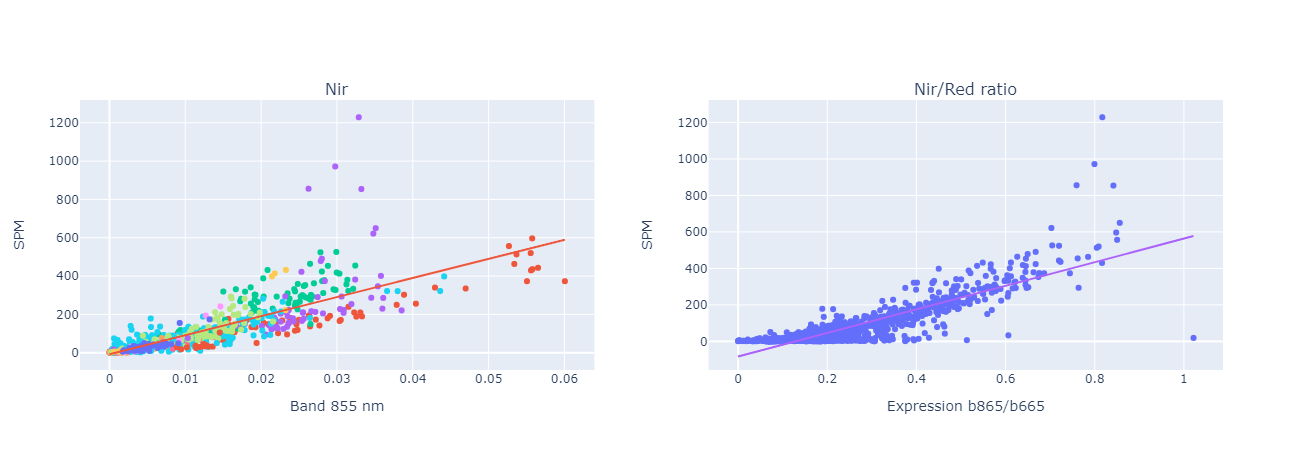

In [ ]:
# Thanks to the multiple plot feature, we can compare the graphs effortlessly
fig = plotly.subplots.make_subplots(rows=1, cols=2, subplot_titles=('Nir', 'Nir/Red ratio'))
fit1.plot_fit(fig=fig, position=(1, 1), color='Rio/ Bacia')
fit2.plot_fit(fig=fig, position=(1, 2), showlegend=False)

## Multiple Fitting
The objective of Multiple Fitting is to fit several functions and bands/expressions at once and get the results as a dataframe.

In [ ]:
#export
class MultiFit:
    "Fits several funcs to the variable/expr_y, using the informed bands/expr_x, and return a dataframe with the results."
    def __init__(self, df, lst_expr_x, funcs, expr_y='SPM'):

        self.fits = []
        
        for expr_x in lst_expr_x:
            for func in funcs:
                self.fits.append(DfFit(df, func, expr_x, expr_y))
        
        self.df = df
        self.lst_expr_x = lst_expr_x
        self.lst_funcs = funcs
        self.expr_y = expr_y
        
        self.results_vars = ['r2', 'rmse', 'SSE', 'params']
        
    #################################  FITTING METHODS  #################################       
    def get_fit(self, func, band):
        if func=='bestfit': return self.get_best_fit_obj(**band)
        
        for fit in self.fits:
            if fit.filled():
                if (fit.fit_params['func'] == func) and (fit.fit_params['band'] == band):
                    return fit
            
    @staticmethod
    def fit_filtered(df, bands, funcs, filter_column, filter_value, thresh=10, variable='SPM', metric='r2', criteria='max'):
        "Filters the dataframe by column value and gets the best fit"

        sub_df = df[df[filter_column] == filter_value]

        if len(sub_df) > thresh:
            return MultiFit(sub_df, bands, funcs)
        else:
            return None

        
    #################################  GRAPHING METHODS  #################################       
    def plot_multifit(self, rows, cols, plots, positions, base_height=300, **kwargs):

        titles = [self.get_fit(*plot).title for plot in plots]
#         forlist(map(lambda x: f'Function {x[0]} on band {x[1]}', plots))
        
        fig = plotly.subplots.make_subplots(rows=rows, cols=cols, subplot_titles=titles)
        
        for plot, position in zip(plots, positions):
            fit = self.get_fit(*plot)
            fig = fit.plot_fit(fig=fig, position=position, **kwargs)
        
        
        fig.update_layout(height=base_height*rows)
        
        return fig
    
    def plot_best_fit(self, metric='r2', criteria='max', **kwargs):
        return self.plot_multifit(1, 1, [('bestfit', {'metric': metric, 'criteria': criteria})], positions=[(1,1)], **kwargs)
    
    #################################  BEST FIT METHODS  #################################        
    def get_best_fit(self, metric='r2', criteria='max'):
        "Retrieve the summary of the best fit among the fits within this object"
        fits = self.get_results_df()
        
        scores = fits.loc[(fits.index.levels[0], metric), :]
        idx_name, band = MultiFit.get_best_score(scores)
        
        res_df = fits.loc[idx_name[0][0], band[0]]
        return res_df.append(pd.Series({'band': band[0], 'func': idx_name[0][0], 'qty': len(self.df), 'ids': self.df['Id'].to_list()}))    
    
    def get_best_fit_obj(self, metric='r2', criteria='max'):
        "Retrieve the actual best fit object. Uses get_best_fit to decide among the results."
        best_fit = self.get_best_fit(metric=metric, criteria=criteria)
        
        return self.get_fit(best_fit['func'], best_fit['band'])

    @staticmethod
    def get_best_score(df, criteria='max', priority_funcs=['linear', 'power', 'nechad', 'expo']):
        "Given a dataframe with scores, get the best combination (function and band), that meets the logic criteria (max or min)"

        # Get the function for the criteria
        criteria = pd.DataFrame.max if criteria=='max' else pd.DataFrame.min

        # Get the lists of indexes and columns of elements that meet the criteria
        idxs, cols = np.where(df == criteria(criteria(df, skipna=True)))

        # If there is more than one result, we have to get the one in the higher function piority
        idxs_names = df.index[idxs]

        # Get the loc of the best solution given the priority functions
        loc = 0
        for func in priority_funcs:
            try:
                loc = idxs_names.get_loc(func)

                # If the function appears more than once, gets the first result 
                # TODO: update to work with priority bands combinations 
                if isinstance(loc, np.ndarray): loc = np.where(loc == True)[0][0]

                break

            except:
                pass

        idxs = [idxs[loc]] if isinstance(loc, np.int64) else idxs[loc]
        cols = [cols[loc]] if isinstance(loc, np.int64) else cols[loc]
        return df.index[idxs], df.columns[cols]
        
    #################################  OTHER METHODS  #################################     
    def get_title(self, metric='r2', criteria='max'): 
        best_fit = self.get_best_fit_obj(metric=metric, criteria=criteria)
        return f'func {best_fit.func.__name__} on {best_fit.expr_x}'
    
    
    def get_results_df(self):
        results = {}

        for expr_x in self.lst_expr_x:
            res_func = {}
            for func in self.lst_funcs:
                # get the saved fit
                fit = self.get_fit(func, expr_x)
                
                for key in self.results_vars:
                    res_func.update({(func, key): fit.fit_params[key] if fit and fit.filled() else None})

            results.update({expr_x: res_func})
        
        return pd.DataFrame.from_dict(results)    
    
    def __repr__(self):
        s = f'Multifit class with {len(self.fits)} fits on variable ({self.expr_y}): df with {len(self.df)}rows, bands:{self.lst_expr_x} funcs{self.lst_funcs} '
        return s


In [ ]:
#example: Fit a linear and a power function using Nir or Nir/Red as independent variables
mfit = MultiFit(df, ['865', 'b865/b665'], ['linear', 'expo'], expr_y='SPM')
mfit

Multifit class with 4 fits on variable (SPM): df with 930rows, bands:['865', 'b865/b665'] funcs['linear', 'expo'] 

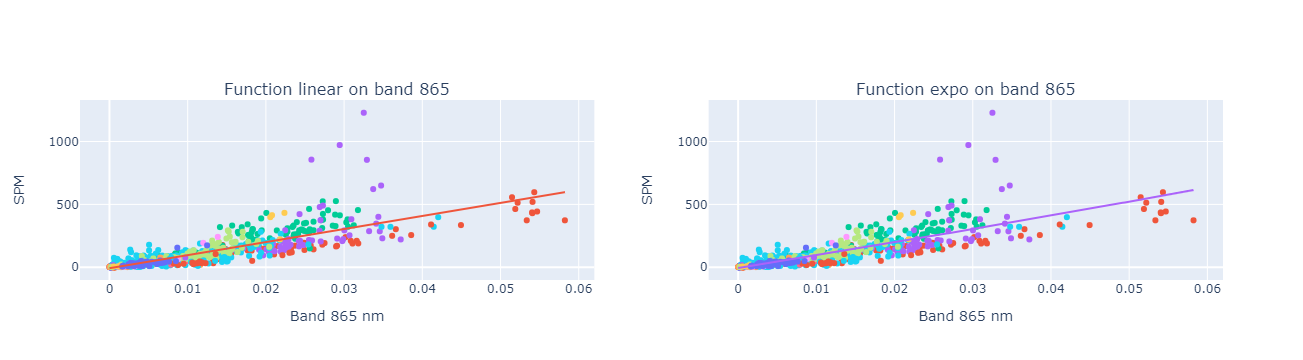

In [ ]:
mfit.plot_multifit(1, 2, [('linear', '865'), ('expo', '865')], positions=[(1,1), (1, 2)], color='Rio/ Bacia', showlegend=False)

In [ ]:
mfit.get_results_df()

865  \
linear r2                                         0.7037   
       rmse                                       68.774   
       SSE                                   4.39877e+06   
       params  [10381.834432996682, -7.4337205515036855]   
expo   r2                                         0.7023   
       rmse                                      68.9395   
       SSE                                   4.41996e+06   
       params    [4321.869859568065, -4327.458505794469]   

                                               b865/b665  
linear r2                                         0.7217  
       rmse                                      66.6451  
       SSE                                   4.13066e+06  
       params    [646.0297541806099, -82.78670036655214]  
expo   r2                                         0.7477  
       rmse                                      63.4588  
       SSE                                   3.74512e+06  
       params  [109.83545565295285, -130.49817746794386]

In [ ]:
show_doc(MultiFit.fit_filtered)

<h4 id="MultiFit.fit_filtered" class="doc_header"><code>MultiFit.fit_filtered</code><a href="__main__.py#L28" class="source_link" style="float:right">[source]</a></h4>

> <code>MultiFit.fit_filtered</code>(**`df`**, **`bands`**, **`funcs`**, **`filter_column`**, **`filter_value`**, **`thresh`**=*`10`*, **`variable`**=*`'SPM'`*, **`metric`**=*`'r2'`*, **`criteria`**=*`'max'`*)

Filters the dataframe by column value and gets the best fit

In [ ]:
filtered_fit = MultiFit.fit_filtered(df, ['865', 'b865/b665'], ['linear', 'expo'], variable='SPM', filter_column='Rio/ Bacia', filter_value='Amazonas')
filtered_fit

Multifit class with 4 fits on variable (SPM): df with 232rows, bands:['865', 'b865/b665'] funcs['linear', 'expo'] 

## Best Fitting
The best fitting functions perform initially a multiple fitting (using multiple functions and combinations) and selects the best solution according to a defined metric and criteria.<br>
The metric can be any of the errors and the criteria can be 'max' or 'min'

In [ ]:
show_doc(MultiFit.get_best_fit)

<h4 id="MultiFit.get_best_fit" class="doc_header"><code>MultiFit.get_best_fit</code><a href="__main__.py#L61" class="source_link" style="float:right">[source]</a></h4>

> <code>MultiFit.get_best_fit</code>(**`metric`**=*`'r2'`*, **`criteria`**=*`'max'`*)

Retrieve the summary of the best fit among the fits within this object

In [ ]:
mfit.get_best_fit()

r2                                                   0.7477
rmse                                                63.4588
SSE                                             3.74512e+06
params            [109.83545565295285, -130.49817746794386]
band                                              b865/b665
func                                                   expo
qty                                                     930
ids       [0, 1, 2, 3, 4, 5, 6, 7, 8, 9, 10, 11, 12, 13,...
dtype: object

Its also possible to compare the best fit with other fittings. Example:

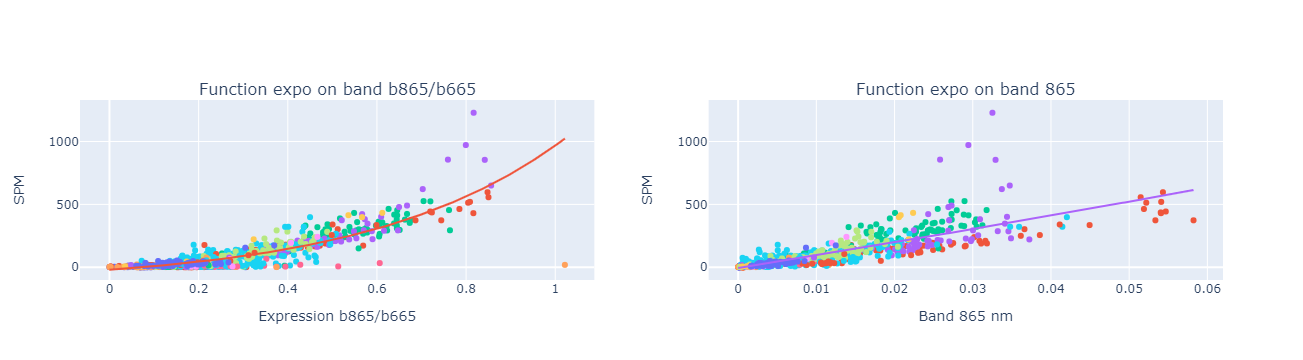

In [ ]:
mfit.plot_multifit(1, 2, plots=[('bestfit',{'metric': 'r2', 'criteria': 'max'}), ('expo', '865')], positions=[(1,1), (1, 2)], color='Rio/ Bacia', showlegend=False)

## Grouped Fitting
Group by the unique values of a column in the dataframe. Fit one MultiFit object for each group. 

In [ ]:
#export
import pdb
class GroupFit:
    def __init__(self, df, bands, funcs, group_column, variable='SPM', metric='r2', criteria='max', ignore_none=True, thresh=10):
        "Loop through the unique values of the group_column and for each group, perform MultiFits according to bands and functions"

        group_fits = {}
        
        for group in df[group_column].unique():
            sub_df = df[df[group_column] == group]
            
            group_fit = MultiFit.fit_filtered(df, bands, funcs, group_column, group, 
                                              thresh=thresh, variable=variable, metric=metric, criteria=criteria)
            
            if ignore_none and (group_fit is not None): group_fits.update({group: group_fit})

        self.df = df
        self.bands = bands
        self.funcs = funcs 
        self.group_column = group_column 
        self.variable = variable
        self.metric = metric 
        self.criteria = criteria
        self.group_fits = group_fits
        
        
#         self.results = self.calc_grouped_metric(df, pd.DataFrame.from_dict(results, orient='index'), dic_funcs)

    def get_results(self):
        results = {}
        
        for group, fit in self.group_fits.items():
            results.update({group: fit.get_best_fit()})
        return pd.DataFrame.from_dict(results, orient='index')
    
    @staticmethod
    def plot_position(cols, linpos): return (linpos//cols+1, linpos%cols+1)
    
    def plot_group(self, group, **kwargs):
        group_fit = self.group_fits[group]
        return group_fit.plot_best_fit(metric=self.metric, criteria=self.criteria, **kwargs)
    
    def plot_groups(self, rows, cols, groups=None, showlegend=True, base_height=300, **kwargs):
        groups = self.group_fits.keys() if groups is None else groups
        
        titles = [f'{group}: ' + self.group_fits[group].get_title(metric=self.metric, criteria=self.criteria) for group in groups]
        
        fig = plotly.subplots.make_subplots(rows=rows, cols=cols, subplot_titles=titles)
        
        for i, group in enumerate(groups):
            group_plot = self.plot_group(group, **kwargs)
            fig = core.apply_subplot(fig, group_plot, self.plot_position(cols, i))
        
        fig.update_layout(showlegend=showlegend, height=base_height*rows)
        return fig
    
    def get_grouped_results(self):
        results = self.get_results()
        grouped_metric = self.calc_grouped_metric_()
        return results.append(pd.Series({key: grouped_metric[key] for key in ['r2', 'rmse', 'SSE', 'qty', 'ids']}).rename('Overall')) 
        
    def calc_grouped_metric_(self):
        "Calculates the metrics considering all the best fits in the group and return as a dictionary"
        preds = []
        targs = []
        for group_fit in self.group_fits.values():
            fit = group_fit.get_best_fit_obj()
            preds = preds + list(fit.fit_params['y_hat'])
            targs = targs + list(fit.fit_params['y'])
            
        grouped_metric = Fit.test_fit(preds, targs, func=None)
        grouped_metric.update({'ids': self.df['Id'].to_list()})
        return grouped_metric

In [ ]:
# To test, we will get the best fit by river/basin and calculate the overall result
gfit = GroupFit(df, ['865', 'b865/b665'], ['linear', 'expo'], 'Rio/ Bacia')
gfit.get_results()

,r2,rmse,SSE,params,band,func,qty,ids
Paranoa,0.7795,2.3968,557.2498,"[4180.256911792661, 1.462421036905868]",865,linear,97,"[0, 1, 2, 3, 4, 5, 6, 7, 8, 9, 10, 11, 12, 13,..."
Sao Francisco,0.9358,19.7827,37961.3010,"[7004.369887746539, -3.8921091092773845]",865,linear,97,"[97, 98, 99, 100, 101, 102, 103, 104, 105, 106..."
Madeira Low,0.8499,50.1565,249051.2959,"[730.3951355405421, -103.33944133320804]",b865/b665,linear,99,"[173, 174, 175, 176, 177, 178, 179, 180, 181, ..."
Madeira High,0.8447,88.8071,457428.9981,"[174.86741581934535, -306.1131518285768]",b865/b665,expo,58,"[194, 195, 196, 197, 198, 199, 200, 201, 202, ..."
Paranapanema,0.6272,6.4820,2100.7981,"[3607.462384037381, 2.0707440872539586]",865,linear,50,"[209, 210, 211, 212, 214, 215, 216, 217, 218, ..."
Amazonas,0.6407,33.9602,267565.0441,"[3268.517018720552, -3256.5757602563285]",865,expo,232,"[260, 353, 354, 361, 362, 363, 372, 373, 374, ..."
Floodplain,0.8796,6.0690,1362.8279,"[2332.7572102740005, -2332.578726865591]",865,expo,37,"[261, 355, 356, 357, 368, 369, 379, 380, 381, ..."
Solimoes,0.7075,33.9471,95649.6559,"[148.0274225034221, -195.50007700030713]",b865/b665,expo,83,"[262, 263, 264, 265, 266, 267, 268, 269, 270, ..."
Purus,0.9278,26.2940,26963.5051,"[3589.3870027173716, -3608.7283804457456]",865,expo,39,"[420, 490, 516, 545, 546, 557, 558, 559, 560, ..."
Volta,0.9755,32.2272,29080.5159,"[751.7684014079063, -111.64596312157856]",b865/b665,linear,28,"[621, 622, 623, 624, 625, 626, 627, 628, 629, ..."


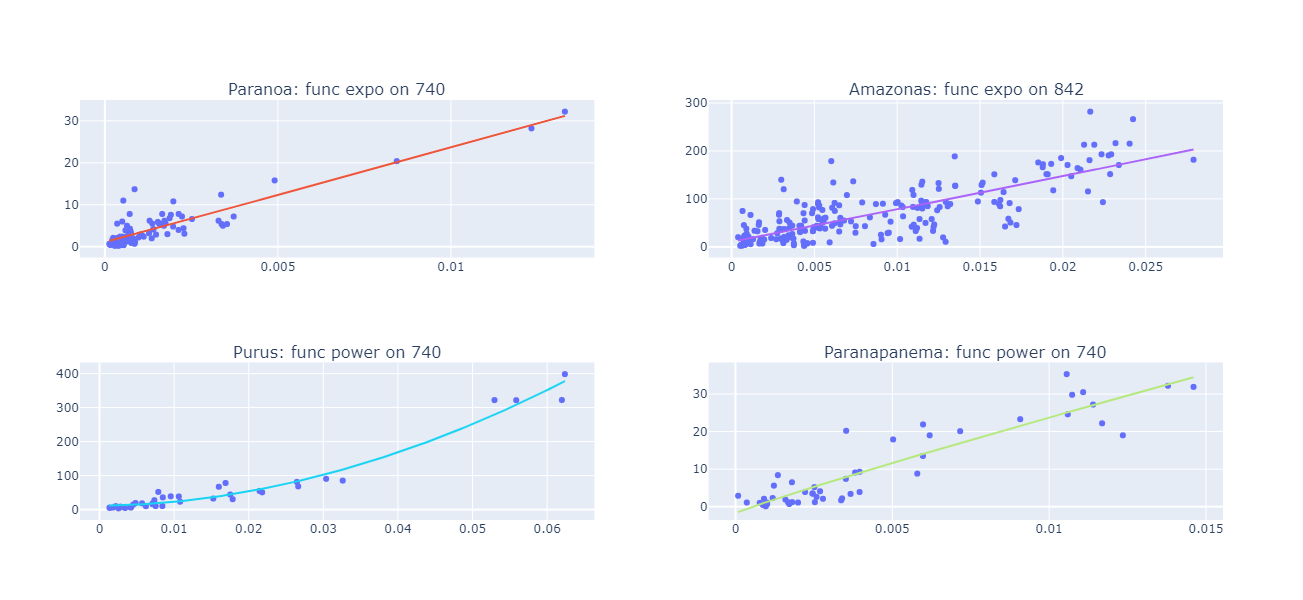

In [ ]:
gfit.plot_groups(2, 2, ('Paranoa', 'Amazonas', 'Purus', 'Paranapanema'), showlegend=False, base_height=300)

In [ ]:
show_doc(GroupFit.get_grouped_results)

<h4 id="GroupFit.get_grouped_results" class="doc_header"><code>GroupFit.get_grouped_results</code><a href="__main__.py#L57" class="source_link" style="float:right">[source]</a></h4>

> <code>GroupFit.get_grouped_results</code>()



In [ ]:
# to test even further, we will check the overall result testing with all Sentinel 2 bands and without the band ratio
s2bands = ['443', '490', '560', '665', '705', '740', '783', '842', '865', '940']
gfit = GroupFit(df, s2bands, Fit.available_funcs, 'Rio/ Bacia')

In [ ]:
gfit.get_grouped_results() 

,r2,rmse,SSE,params,band,func,qty,ids
Paranoa,0.8099,2.2256,4.804851e+02,"[967.5209975532641, -966.4025327499623]",740,expo,97,"[0, 1, 2, 3, 4, 5, 6, 7, 8, 9, 10, 11, 12, 13,..."
Sao Francisco,0.9372,19.5543,3.709009e+04,"[7595.279402270282, 1.0614996972334543, -2.913...",842,power,97,"[97, 98, 99, 100, 101, 102, 103, 104, 105, 106..."
Madeira Low,0.7855,59.9586,3.559088e+05,"[3434.908048808383, 0.4348813112159943, -359.3...",865,power,99,"[173, 174, 175, 176, 177, 178, 179, 180, 181, ..."
Madeira High,0.5646,148.7141,1.282722e+06,"[1.0972308206100366e-06, -5.719508151895633, 1...",560,power,58,"[194, 195, 196, 197, 198, 199, 200, 201, 202, ..."
Paranapanema,0.8465,4.1594,8.650203e+02,"[1835.7906427453788, 0.9286400715402091, -1.76...",740,power,50,"[209, 210, 211, 212, 214, 215, 216, 217, 218, ..."
Amazonas,0.6420,33.8963,2.665585e+05,"[2900.4155947610707, -2889.5877058329156]",842,expo,232,"[260, 353, 354, 361, 362, 363, 372, 373, 374, ..."
Floodplain,0.8808,6.0398,1.349722e+03,"[2012.2434839081047, -2012.049591602078]",842,expo,37,"[261, 355, 356, 357, 368, 369, 379, 380, 381, ..."
Solimoes,0.6203,38.6815,1.241896e+05,"[129055.10469384732, 1.6756541587582459, 18.15...",842,power,83,"[262, 263, 264, 265, 266, 267, 268, 269, 270, ..."
Purus,0.9690,17.2413,1.159329e+04,"[74076.46457124266, 1.9143559443727851, 11.987...",740,power,39,"[420, 490, 516, 545, 546, 557, 558, 559, 560, ..."
Volta,0.9474,47.2021,6.238495e+04,"[28261.94279493153, 1.0533405381292342, -64.55...",940,power,28,"[621, 622, 623, 624, 625, 626, 627, 628, 629, ..."


### Testing different grouping

In [ ]:
df.loc[df['SPM']>100,  'SPM_Group'] = 'HighSPM'
df.loc[df['SPM']<=100, 'SPM_Group'] = 'LowSPM'

In [ ]:
gfit = GroupFit(df, s2bands, Fit.available_funcs, 'SPM_Group')
gfit.get_grouped_results()

,r2,rmse,SSE,params,band,func,qty,ids
LowSPM,0.6440,17.0786,1.907573e+05,"[1091.7731212933486, 0.630182735306514, -5.306...",842,power,654,"[0, 1, 2, 3, 4, 5, 6, 7, 8, 9, 10, 11, 12, 13,..."
HighSPM,0.3471,115.1216,3.657824e+06,"[5030.78392817862, 0.7848353248992973, -6.3259...",865,power,276,"[97, 123, 137, 139, 140, 141, 142, 143, 144, 1..."
Overall,0.7407,64.3293,3.848581e+06,NaN,NaN,NaN,930,"[0, 1, 2, 3, 4, 5, 6, 7, 8, 9, 10, 11, 12, 13,..."


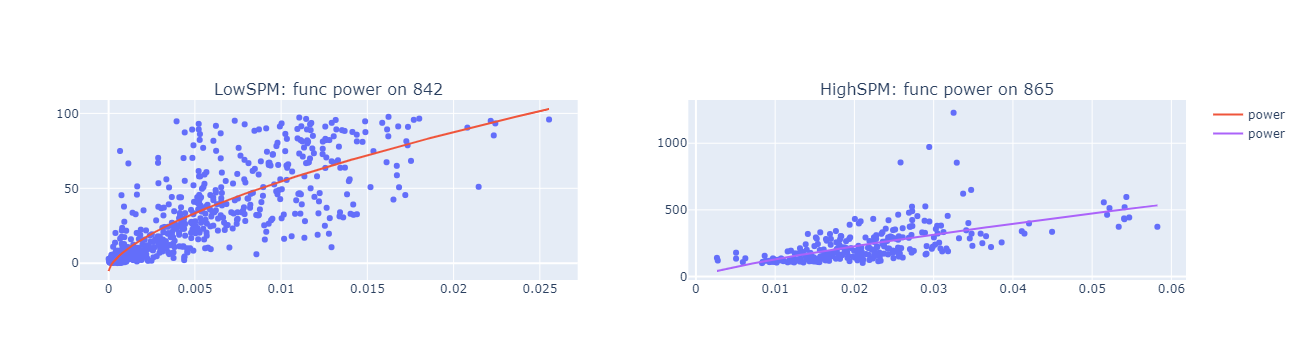

In [ ]:
gfit.plot_groups(1, 2)